# data.xlsx — Keşifsel Veri Analizi (EDA)

21.2 GHz frekanslı, 2.8 km mesafeli bir mikrodalga radyo bağlantısına ait ~1 aylık (Haziran–Temmuz 2014) ölçüm verisi.

| Sheet | İçerik | Granülarite |
|-------|--------|-------------|
| `21.2GHz 2.8 km` | RSL / TSL sinyal seviyeleri | 15 dakika |
| `Sheet2` | RSL + meteoroloji (sıcaklık, nem, yağış…) | 1 dakika |

In [4]:
# Veri analizi için gerekli kütüphaneleri içe aktarıyoruz:
#   numpy  → sayısal hesaplamalar (dizi işlemleri, istatistik)
#   pandas → tablo (DataFrame) yapısı, veri okuma/yazma
#   matplotlib & seaborn → grafik çizimi
#   scipy  → istatistiksel testler (t-test, linregress)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Grafik teması: beyaz arka plan, derin renk paleti
sns.set_theme(style="whitegrid", palette="deep")

# Pandas ayarları: tüm sütunları göster, sayıları 4 ondalık ile yaz
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Dosya yolu — değiştirmek gerekirse burası yeterli
FILE = "data.xlsx"


## 1. Veriyi Okuma

In [5]:
# ── SHEET 1: Radio (15 dakikalık RSL/TSL ölçümleri) ──────────────────────────
# Sütun adlarındaki baştaki/sondaki boşlukları temizliyoruz
radio = pd.read_excel(FILE, sheet_name="21.2GHz 2.8 km ")
radio.columns = radio.columns.str.strip()

# "Collection Time" sütunu "02/06/2014 00:00:00 UTC+03:00" formatında geliyor.
# UTC+03:00 ifadesini kaldırıp standart datetime'a çeviriyoruz (dayfirst=True → GG/AA/YYYY)
radio["Collection Time"] = (
    radio["Collection Time"]
    .astype(str)
    .str.replace(" UTC+03:00", "", regex=False)
)
radio["Collection Time"] = pd.to_datetime(radio["Collection Time"], dayfirst=True, errors="coerce")

# Zamansal sıralamayı garantiye alıyoruz
radio = radio.sort_values("Collection Time").reset_index(drop=True)

# ── SHEET 2: Weather (1 dakikalık meteoroloji + RSL) ─────────────────────────
# Excel'de başlık satırı 2. satırda, 1. satır boş — bunu elle çözüyoruz
raw = pd.read_excel(FILE, sheet_name="Sheet2", header=None).dropna(how="all").reset_index(drop=True)
weather = raw.iloc[1:].copy()             # 2. satırdan itibaren veri
weather.columns = raw.iloc[0].astype(str).str.strip()  # 1. satır başlık

# Sütun adlarını daha okunabilir kısaltmalara dönüştürüyoruz
weather = weather.rename(columns={
    "TEMP (ｰC)": "TEMP_C",         # Japonca derece karakterini düzeltiyoruz
    "RH (%)": "RH_pct",            # Bağıl nem
    "1H RAIN (MM)": "RAIN_mm",     # Saatlik yağış
    "WSINS (KT)": "WIND_kt",       # Rüzgar hızı (knot)
    "PAINS (HPA)": "PRESS_hpa",    # Atmosferik basınç
    "Refrence": "RSL_ref",         # Referans (yazım hatası → düzeltildi)
    "History file UTC Time": "time",
    "dB/km": "dB_km"
})

# Zaman sütununu datetime'a çevirip sıralıyoruz
weather["time"] = pd.to_datetime(weather["time"], errors="coerce")
weather = weather.sort_values("time").reset_index(drop=True)

print("Radio shape :", radio.shape)    # (satır, sütun)
print("Weather shape:", weather.shape)


Radio shape : (2607, 7)
Weather shape: (39074, 11)


## 2. Veri Yapısı — `.info()` ve `.head()`

In [6]:
# .info() → her sütunun adını, null-olmayan kayıt sayısını ve veri tipini gösterir.
# Hangi sütunlar object (metin) olarak kalmış, hangilerinde eksik var — ilk bakış için kritik.
print("=" * 55)
print("RADIO — .info()")
print("=" * 55)
radio.info()

print("\n")
print("=" * 55)
print("WEATHER — .info()")
print("=" * 55)
weather.info()


RADIO — .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Resource Name    2606 non-null   object        
 1   Collection Time  2605 non-null   datetime64[ns]
 2   Granularity      2606 non-null   object        
 3   RSL_MAX(dBm)     2606 non-null   object        
 4   RSL_MIN(dBm)     2606 non-null   object        
 5   TSL_MAX(dBm)     2606 non-null   object        
 6   TSL_MIN(dBm)     2606 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 142.7+ KB


WEATHER — .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39074 entries, 0 to 39073
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   time       39074 non-null  datetime64[ns]
 1   MOR_1A     39074 non-null  object        
 2   TEMP_C     39074 n

In [7]:
# .head() → tablonun ilk 5 satırını gösterir.
# Verilerin nasıl göründüğünü, birimleri ve biçimi hızlıca anlamak için kullanılır.
print("RADIO — ilk 5 satır")
display(radio.head())

print("\nWEATHER — ilk 5 satır")
display(weather.head())


RADIO — ilk 5 satır


,Resource Name,Collection Time,Granularity,RSL_MAX(dBm),RSL_MIN(dBm),TSL_MAX(dBm),TSL_MIN(dBm)
0,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:00:00,15 Min(maygooma events),-44.3000,-46.1000,-55,-55
1,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:15:00,15 Min(maygooma events),-45.3000,-45.9000,-55,-55
2,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:30:00,15 Min(maygooma events),-45.4000,-45.9000,-55,-55
3,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:45:00,15 Min(maygooma events),-45.1000,-45.8000,-55,-55
4,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 01:00:00,15 Min(maygooma events),-45.2000,-45.6000,-55,-55



WEATHER — ilk 5 satır


,time,MOR_1A,TEMP_C,RH_pct,PRESS_hpa,RAIN_mm,WIND_kt,RSL,RSL_ref,dB,dB_km
0,2014-06-01 21:00:00,4400,36.2000,23,962.7000,0,5.6400,-46.1000,-43.8000,2.3000,0.8214
1,2014-06-01 21:01:00,4500,36.1000,23,962.7000,0,5.2500,-46.1000,-43.8000,2.3000,0.8214
2,2014-06-01 21:02:00,4600,36.1000,23,962.7000,0,4.4700,-46.1000,-43.8000,2.3000,0.8214
3,2014-06-01 21:03:00,4600,36.1000,23,962.8000,0,4.2800,-46.1000,-43.8000,2.3000,0.8214
4,2014-06-01 21:04:00,4700,36.1000,23,962.8000,0,5.2500,-46.1000,-43.8000,2.3000,0.8214


## 3. Veri Tipi Dönüşümleri

Ham Excel okumada bazı sütunlar `object` olarak geliyor. Sayısal ve kategorik dönüşümler burada yapılıyor.

In [8]:
# ── Radio: Sayısal Dönüşümler ────────────────────────────────────────────────
# Excel'den okunan bazı sütunlar "object" (metin) tipinde gelebilir.
# pd.to_numeric(..., errors="coerce") → sayıya çevrilemeyen değerleri NaN yapar
radio_num_cols = ["RSL_MAX(dBm)", "RSL_MIN(dBm)", "TSL_MAX(dBm)", "TSL_MIN(dBm)"]
for col in radio_num_cols:
    radio[col] = pd.to_numeric(radio[col], errors="coerce")

# ── Weather: Sayısal Dönüşümler ──────────────────────────────────────────────
weather_num_cols = ["MOR_1A", "TEMP_C", "RH_pct", "PRESS_hpa", "RAIN_mm",
                    "WIND_kt", "RSL", "RSL_ref", "dB", "dB_km"]
for col in weather_num_cols:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

# MOR_1A → Meteorolojik Optik Menzil (görüş mesafesi, metre cinsinden).
# Değerler zaten tam sayı (100, 200, … 10000), ondalık kısım hatalı yuvarlama.
# Int64 (büyük I) → pandas'ın NaN destekleyen tam sayı tipi (normal int NaN alamaz)
weather["MOR_1A"] = weather["MOR_1A"].round().astype("Int64")

print("Dönüşüm sonrası tipler:")
print("\nRADIO dtypes:")
print(radio.dtypes)
print("\nWEATHER dtypes:")
print(weather.dtypes)


Dönüşüm sonrası tipler:

RADIO dtypes:
Resource Name              object
Collection Time    datetime64[ns]
Granularity                object
RSL_MAX(dBm)              float64
RSL_MIN(dBm)              float64
TSL_MAX(dBm)              float64
TSL_MIN(dBm)              float64
dtype: object

WEATHER dtypes:
0
time         datetime64[ns]
MOR_1A                Int64
TEMP_C              float64
RH_pct              float64
PRESS_hpa           float64
RAIN_mm             float64
WIND_kt             float64
RSL                 float64
RSL_ref             float64
dB                  float64
dB_km               float64
dtype: object


## 4. Özet İstatistikler — `.describe()`

In [9]:
# .describe() → temel istatistikleri bir tablo olarak verir:
#   count  → kaç kayıt var (eksikler dahil değil)
#   mean   → ortalama
#   std    → standart sapma (dağılımın yayıklığı)
#   min/max → en küçük/büyük değer
#   %5, %25, %50, %75, %95 → dağılımın yüzdelik dilimleri
# .T → tabloyu devirerek sütunlar = istatistikler, satırlar = değişkenler yapar (daha okunur)
print("RADIO — describe()")
display(radio[radio_num_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

print("\nWEATHER — describe()")
display(weather[weather_num_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)


RADIO — describe()


,count,mean,std,min,5%,25%,50%,75%,95%,max
RSL_MAX(dBm),"2,605.0000",-44.5000,0.5810,-45.7000,-45.4000,-45.0000,-44.5000,-44.1000,-43.5000,-42.3000
RSL_MIN(dBm),"2,605.0000",-45.6507,0.5396,-53.2000,-46.3000,-46.0000,-45.7000,-45.4000,-44.7200,-44.1000
TSL_MAX(dBm),"2,605.0000",-55.0000,0.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000
TSL_MIN(dBm),"2,605.0000",-55.0000,0.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000,-55.0000



WEATHER — describe()


,count,mean,std,min,5%,25%,50%,75%,95%,max
0,,,,,,,,,,
MOR_1A,"39,048.0000","8,688.0032","2,461.2939",100.0000,"2,700.0000","8,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000"
TEMP_C,"39,059.0000",35.6842,4.1299,25.1000,29.2000,32.3000,35.9000,39.2000,41.7000,44.7000
RH_pct,"39,058.0000",21.5730,13.8659,6.0000,7.0000,11.0000,16.0000,31.0000,49.0000,74.0000
PRESS_hpa,"39,060.0000",963.8403,2.1236,958.5000,960.2000,962.3000,964.0000,965.5000,967.1000,968.8000
RAIN_mm,"39,061.0000",0.0009,0.0235,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6000
WIND_kt,"21,428.0000",7.4556,4.6874,0.0000,1.7500,4.0800,6.4100,9.9100,16.5200,35.5700
RSL,"39,074.0000",-45.6507,0.5395,-53.2000,-46.3000,-46.0000,-45.7000,-45.4000,-44.7000,-44.1000
RSL_ref,"39,074.0000",-43.8000,0.0000,-43.8000,-43.8000,-43.8000,-43.8000,-43.8000,-43.8000,-43.8000
dB,"39,074.0000",1.8507,0.5395,0.3000,0.9000,1.6000,1.9000,2.2000,2.5000,9.4000


## 5. Eksik Değer Analizi


RADIO — eksik değer raporu (2607 kayıt)


,eksik_sayi,eksik_pct
Collection Time,2,0.0767
RSL_MAX(dBm),2,0.0767
RSL_MIN(dBm),2,0.0767
TSL_MAX(dBm),2,0.0767
TSL_MIN(dBm),2,0.0767
Resource Name,1,0.0384
Granularity,1,0.0384



WEATHER — eksik değer raporu (39074 kayıt)


,eksik_sayi,eksik_pct
0,,
WIND_kt,17646,45.1605
MOR_1A,26,0.0665
RH_pct,16,0.0409
TEMP_C,15,0.0384
PRESS_hpa,14,0.0358
RAIN_mm,13,0.0333


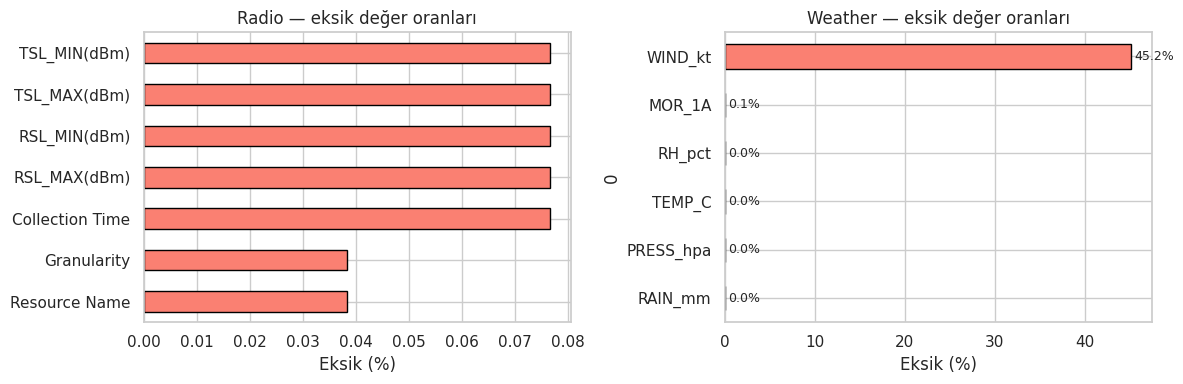

In [10]:
# Eksik değer analizi: hangi sütunda kaç tane NaN var ve bunlar toplam kaydın yüzde kaçı?
def missing_report(df, name):
    miss = df.isna().sum()                        # Her sütun için NaN sayısı
    miss = miss[miss > 0].rename("eksik_sayi")    # Sadece eksik olanları al
    pct  = (miss / len(df) * 100).rename("eksik_pct")
    report = pd.concat([miss, pct], axis=1).sort_values("eksik_pct", ascending=False)
    print(f"\n{name} — eksik değer raporu ({len(df)} kayıt)")
    display(report)

missing_report(radio, "RADIO")
missing_report(weather, "WEATHER")

# Yatay bar grafiği ile görselleştirme — hangi sütun ne kadar eksik
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, name) in zip(axes, [(radio, "Radio"), (weather, "Weather")]):
    miss_pct = df.isna().mean() * 100
    miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)
    if miss_pct.empty:
        ax.set_title(f"{name} — eksik yok")
        ax.axis("off")
    else:
        miss_pct.plot(kind="barh", ax=ax, color="salmon", edgecolor="black")
        ax.set_xlabel("Eksik (%)")
        ax.set_title(f"{name} — eksik değer oranları")
        for p in ax.patches:
            ax.annotate(f"{p.get_width():.1f}%",
                        (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                        va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Feature Engineering — Türetilmiş Değişkenler

In [11]:
# ── Radio: Türetilmiş Değişkenler ────────────────────────────────────────────
# RSL_range_dB → 15 dk içindeki sinyal salınım genişliği (MAX - MIN).
#   Büyük değer = bağlantı o aralıkta kararsız/dalgalı demek.
radio["RSL_range_dB"] = radio["RSL_MAX(dBm)"] - radio["RSL_MIN(dBm)"]

# Günün saati ve tarih bilgisi — zaman bazlı örüntüleri aramak için
radio["hour"] = radio["Collection Time"].dt.hour
radio["date"] = radio["Collection Time"].dt.date

# ── Weather: Türetilmiş Değişkenler ──────────────────────────────────────────
weather["hour"] = weather["time"].dt.hour
weather["date"] = weather["time"].dt.date

# attenuation_dB → referans RSL ile ölçülen RSL arasındaki fark.
#   Referans = yağışsız, nominal koşullardaki beklenen sinyal seviyesi.
#   Fark ne kadar büyükse sinyal o kadar çok zayıflamış demek.
weather["attenuation_dB"] = weather["RSL_ref"] - weather["RSL"]

# Gün içi dilim: örüntüleri 4 kategoride incelemek için (gece/sabah/öğle/akşam)
def time_of_day(h):
    if 0 <= h < 6:   return "gece"
    if 6 <= h < 12:  return "sabah"
    if 12 <= h < 18: return "öğle"
    return "akşam"

weather["time_of_day"] = weather["hour"].apply(time_of_day)

print("Yeni sütunlar — Radio:", ["RSL_range_dB", "hour", "date"])
print("Yeni sütunlar — Weather:", ["hour", "date", "attenuation_dB", "time_of_day"])
display(weather[["time", "RSL", "RSL_ref", "dB", "attenuation_dB", "time_of_day"]].head(8))


Yeni sütunlar — Radio: ['RSL_range_dB', 'hour', 'date']
Yeni sütunlar — Weather: ['hour', 'date', 'attenuation_dB', 'time_of_day']


,time,RSL,RSL_ref,dB,attenuation_dB,time_of_day
0,2014-06-01 21:00:00,-46.1000,-43.8000,2.3000,2.3000,akşam
1,2014-06-01 21:01:00,-46.1000,-43.8000,2.3000,2.3000,akşam
2,2014-06-01 21:02:00,-46.1000,-43.8000,2.3000,2.3000,akşam
3,2014-06-01 21:03:00,-46.1000,-43.8000,2.3000,2.3000,akşam
4,2014-06-01 21:04:00,-46.1000,-43.8000,2.3000,2.3000,akşam
5,2014-06-01 21:05:00,-46.1000,-43.8000,2.3000,2.3000,akşam
6,2014-06-01 21:06:00,-46.1000,-43.8000,2.3000,2.3000,akşam
7,2014-06-01 21:07:00,-46.1000,-43.8000,2.3000,2.3000,akşam


## 7. Kategorik Encoding

`time_of_day` kategorik değişken — modelleme için ikili (dummy) ve ordinal encoding yapılıyor.

In [12]:
# ── Ordinal Encoding ─────────────────────────────────────────────────────────
# Kategorik değişkeni sıralı sayıya çevirme.
# "gece" < "sabah" < "öğle" < "akşam" mantığıyla 0-3 arası tam sayı atanır.
# Bazı modeller (ör. lineer regresyon) kategorik metni doğrudan işleyemez.
tod_order = {"gece": 0, "sabah": 1, "öğle": 2, "akşam": 3}
weather["time_of_day_ord"] = weather["time_of_day"].map(tod_order).astype("Int8")

# ── One-Hot Encoding ─────────────────────────────────────────────────────────
# Her kategori için ayrı 0/1 sütunu oluşturur (dummy değişkenler).
# drop_first=False → tüm kategorileri tutuyoruz (ağaç modelleri için sorun değil)
# pd.get_dummies çıktısı bool, .astype(int) ile 0/1'e çeviriyoruz
tod_dummies = pd.get_dummies(weather["time_of_day"], prefix="tod", drop_first=False).astype(int)
weather = pd.concat([weather, tod_dummies], axis=1)

# ── Yağış Olayı (Binary) ─────────────────────────────────────────────────────
# RAIN_mm > 0 → yağış var (1), yoksa 0.
# NaN değerleri 0 olarak dolduruyoruz (ölçüm yoksa yağış yok kabul ediyoruz)
weather["rain_event"] = weather["RAIN_mm"].fillna(0).gt(0).astype(int)

print("Kategorik encoding sonuçları:")
display(weather[["time_of_day", "time_of_day_ord",
                  "tod_gece", "tod_sabah", "tod_öğle", "tod_akşam",
                  "rain_event"]].drop_duplicates("time_of_day").sort_values("time_of_day_ord"))

print(f"\nYağışlı kayıt: {weather['rain_event'].sum()} ({weather['rain_event'].mean()*100:.2f}%)")
print(f"Yağışsız kayıt: {(~weather['rain_event'].astype(bool)).sum()}")


Kategorik encoding sonuçları:


,time_of_day,time_of_day_ord,tod_gece,tod_sabah,tod_öğle,tod_akşam,rain_event
180,gece,0,1,0,0,0,0
540,sabah,1,0,1,0,0,0
900,öğle,2,0,0,1,0,0
0,akşam,3,0,0,0,1,0



Yağışlı kayıt: 60 (0.15%)
Yağışsız kayıt: 39014


## 8. Zaman Serisi Grafikleri

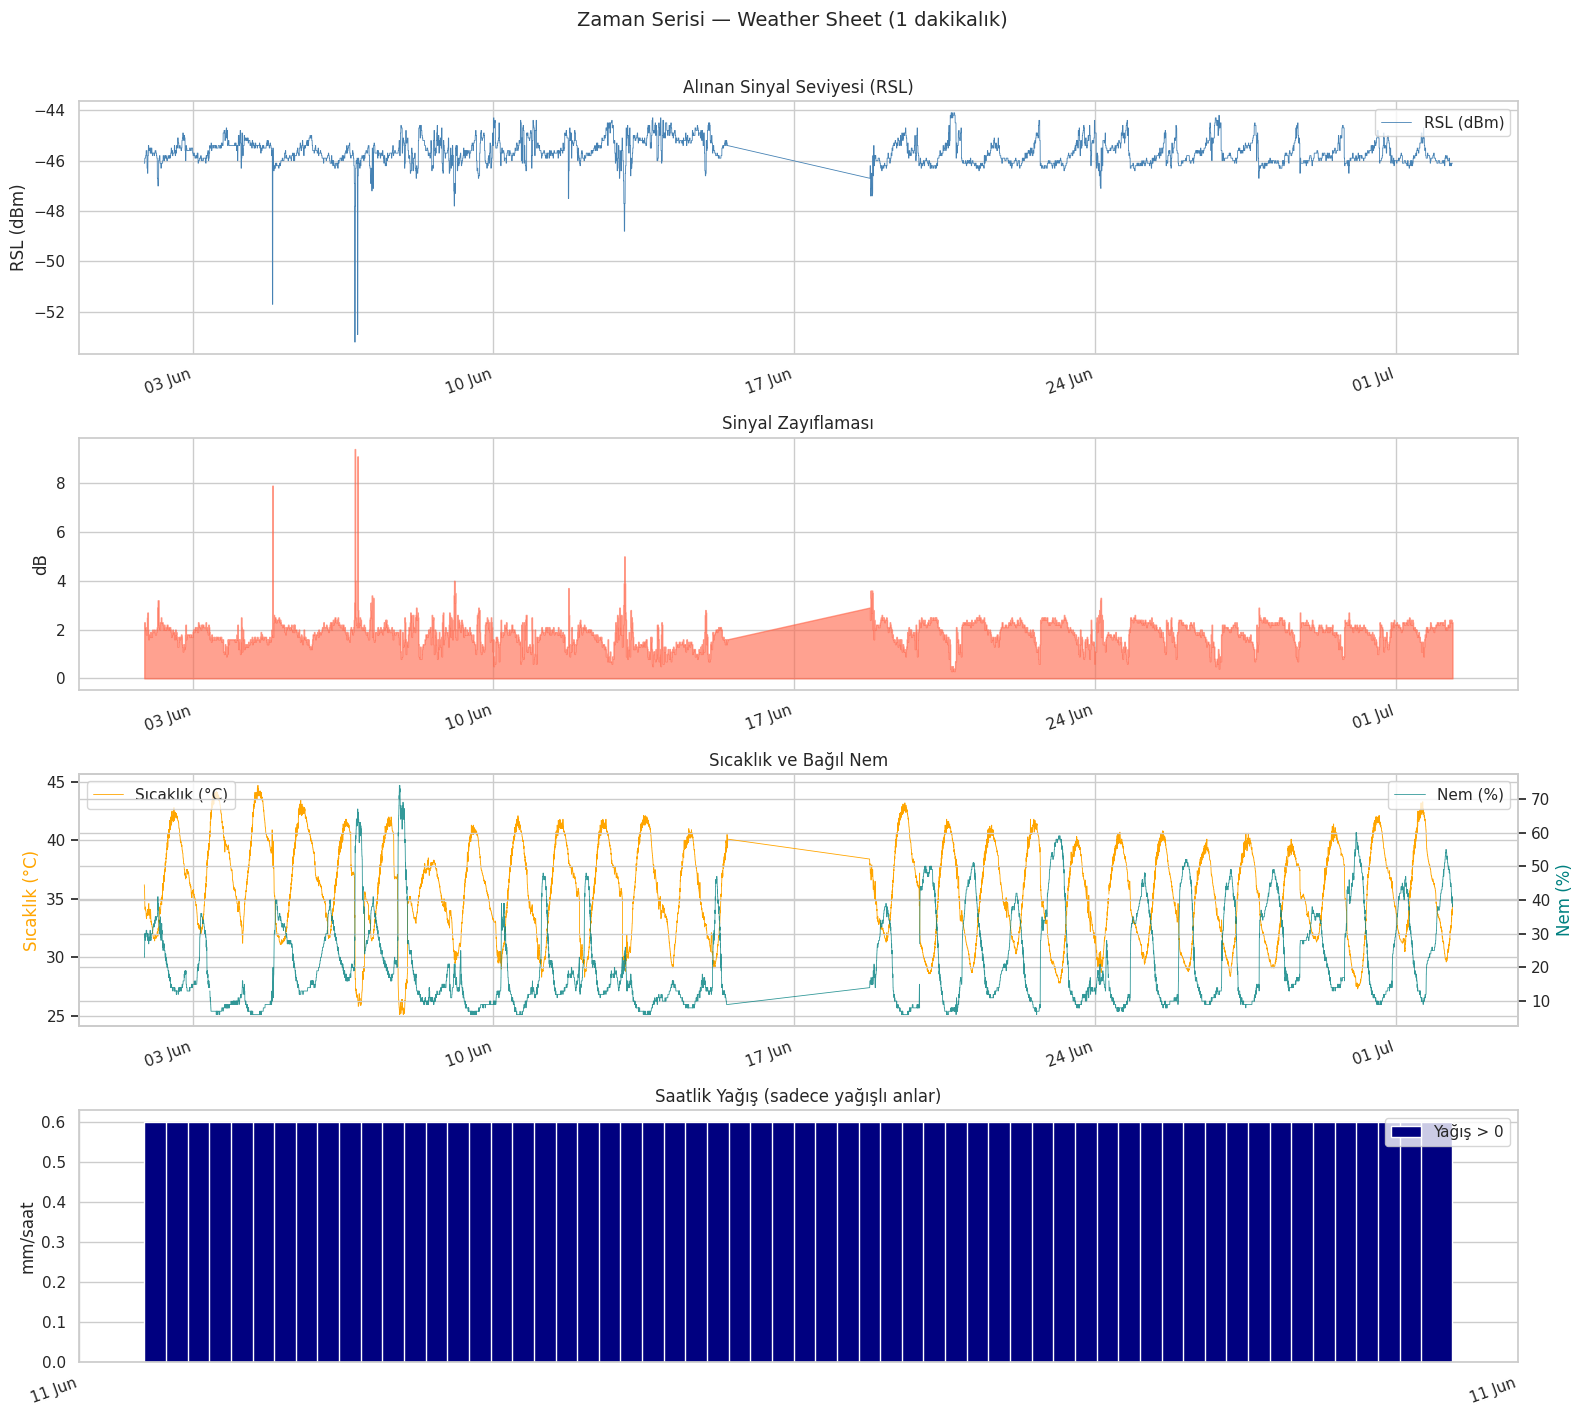

In [13]:
# 4 panelli zaman serisi grafiği — Weather sheet verisindeki trendleri görmek için
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)
fig.suptitle("Zaman Serisi — Weather Sheet (1 dakikalık)", fontsize=14, y=1.01)

# Panel 1: RSL (Received Signal Level) — alınan sinyal gücü (dBm)
# Düşük değer = zayıf sinyal. -50 dBm civarı belirgin düşüşler dikkat çeker.
axes[0].plot(weather["time"], weather["RSL"], lw=0.6, color="steelblue", label="RSL (dBm)")
axes[0].set_ylabel("RSL (dBm)")
axes[0].set_title("Alınan Sinyal Seviyesi (RSL)")
axes[0].legend(loc="upper right")

# Panel 2: Zayıflama (dB) — fill_between ile alan doldurarak büyük olayları vurguluyoruz
axes[1].fill_between(weather["time"], weather["dB"], alpha=0.6, color="tomato")
axes[1].set_ylabel("dB")
axes[1].set_title("Sinyal Zayıflaması")

# Panel 3: Sıcaklık ve Nem — iki farklı ölçek için twinx (ikiz eksen) kullanıyoruz
ax2b = axes[2].twinx()
axes[2].plot(weather["time"], weather["TEMP_C"], lw=0.6, color="orange", label="Sıcaklık (°C)")
ax2b.plot(weather["time"], weather["RH_pct"], lw=0.6, color="teal", alpha=0.8, label="Nem (%)")
axes[2].set_ylabel("Sıcaklık (°C)", color="orange")
ax2b.set_ylabel("Nem (%)", color="teal")
axes[2].set_title("Sıcaklık ve Bağıl Nem")
axes[2].legend(loc="upper left"); ax2b.legend(loc="upper right")

# Panel 4: Yağış — sadece yağış olan anları bar olarak gösteriyoruz
# Verinin büyük çoğunluğu 0 olduğundan tüm veriyi çizmek grafiği karartırdı
rain_mask = weather["RAIN_mm"] > 0
axes[3].bar(weather.loc[rain_mask, "time"], weather.loc[rain_mask, "RAIN_mm"],
            width=0.001, color="navy", label="Yağış > 0")
axes[3].set_ylabel("mm/saat")
axes[3].set_title("Saatlik Yağış (sadece yağışlı anlar)")
axes[3].legend()

# X eksenini tarih formatıyla düzenliyoruz
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()


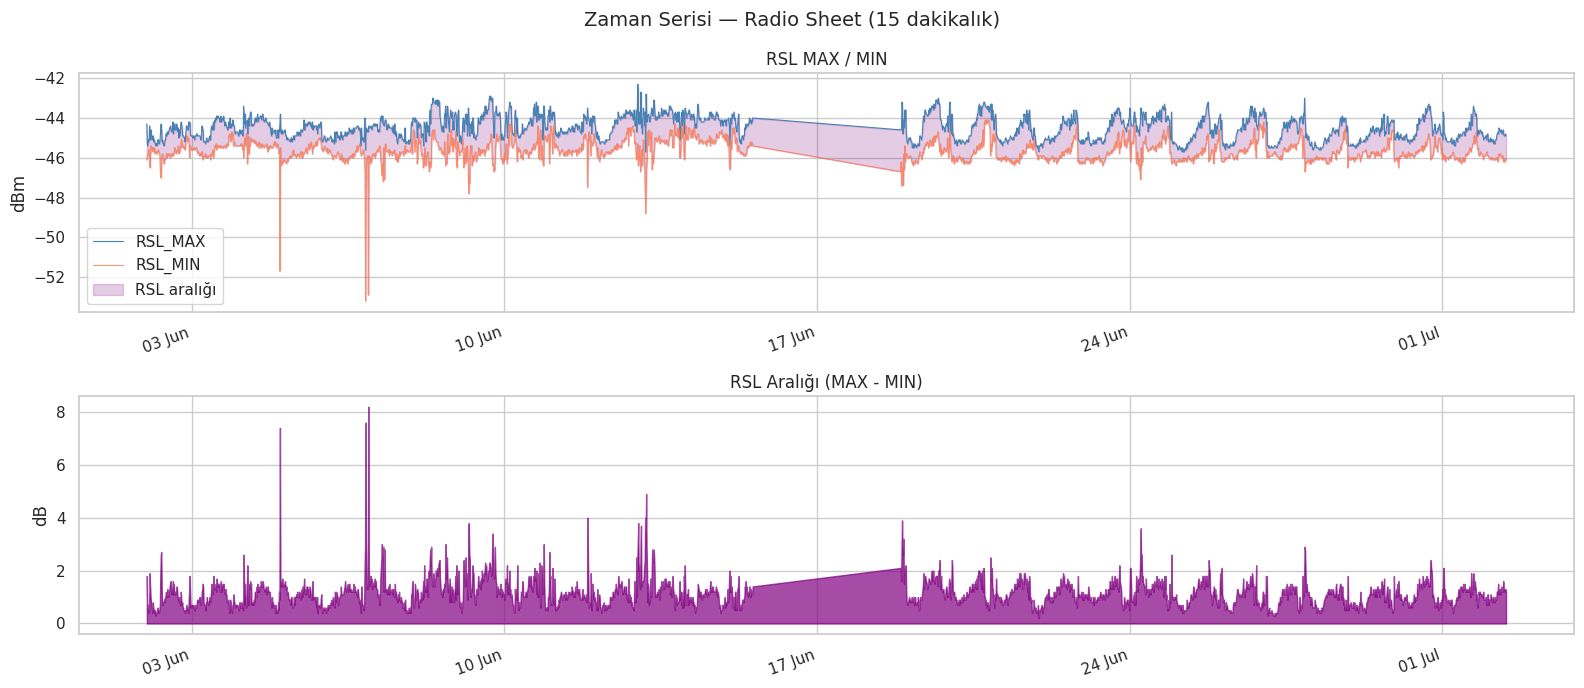

In [14]:
# Radio Sheet zaman serisi — 15 dakikalık RSL MAX/MIN ve aralık (salınım genişliği)
fig, axes = plt.subplots(2, 1, figsize=(16, 7))
fig.suptitle("Zaman Serisi — Radio Sheet (15 dakikalık)", fontsize=14)

radio_clean = radio.dropna(subset=["Collection Time", "RSL_MAX(dBm)"])

# Panel 1: RSL MAX ve MIN — fill_between ile ikisi arasındaki band boyanan alan,
# bağlantının her 15 dk'daki sinyal kararsızlığını (salınım) gösterir
axes[0].plot(radio_clean["Collection Time"], radio_clean["RSL_MAX(dBm)"],
             lw=0.8, color="steelblue", label="RSL_MAX")
axes[0].plot(radio_clean["Collection Time"], radio_clean["RSL_MIN(dBm)"],
             lw=0.8, color="coral", alpha=0.8, label="RSL_MIN")
axes[0].fill_between(radio_clean["Collection Time"],
                     radio_clean["RSL_MIN(dBm)"], radio_clean["RSL_MAX(dBm)"],
                     alpha=0.2, color="purple", label="RSL aralığı")
axes[0].set_ylabel("dBm")
axes[0].set_title("RSL MAX / MIN")
axes[0].legend()

# Panel 2: Sadece aralık (MAX - MIN) — büyük değerler o 15 dk'da sinyal çok dalgalandı demek
axes[1].fill_between(radio_clean["Collection Time"], radio_clean["RSL_range_dB"],
                     alpha=0.7, color="purple")
axes[1].set_ylabel("dB")
axes[1].set_title("RSL Aralığı (MAX - MIN)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()


## 9. Dağılım Grafikleri (Histogramlar & KDE)

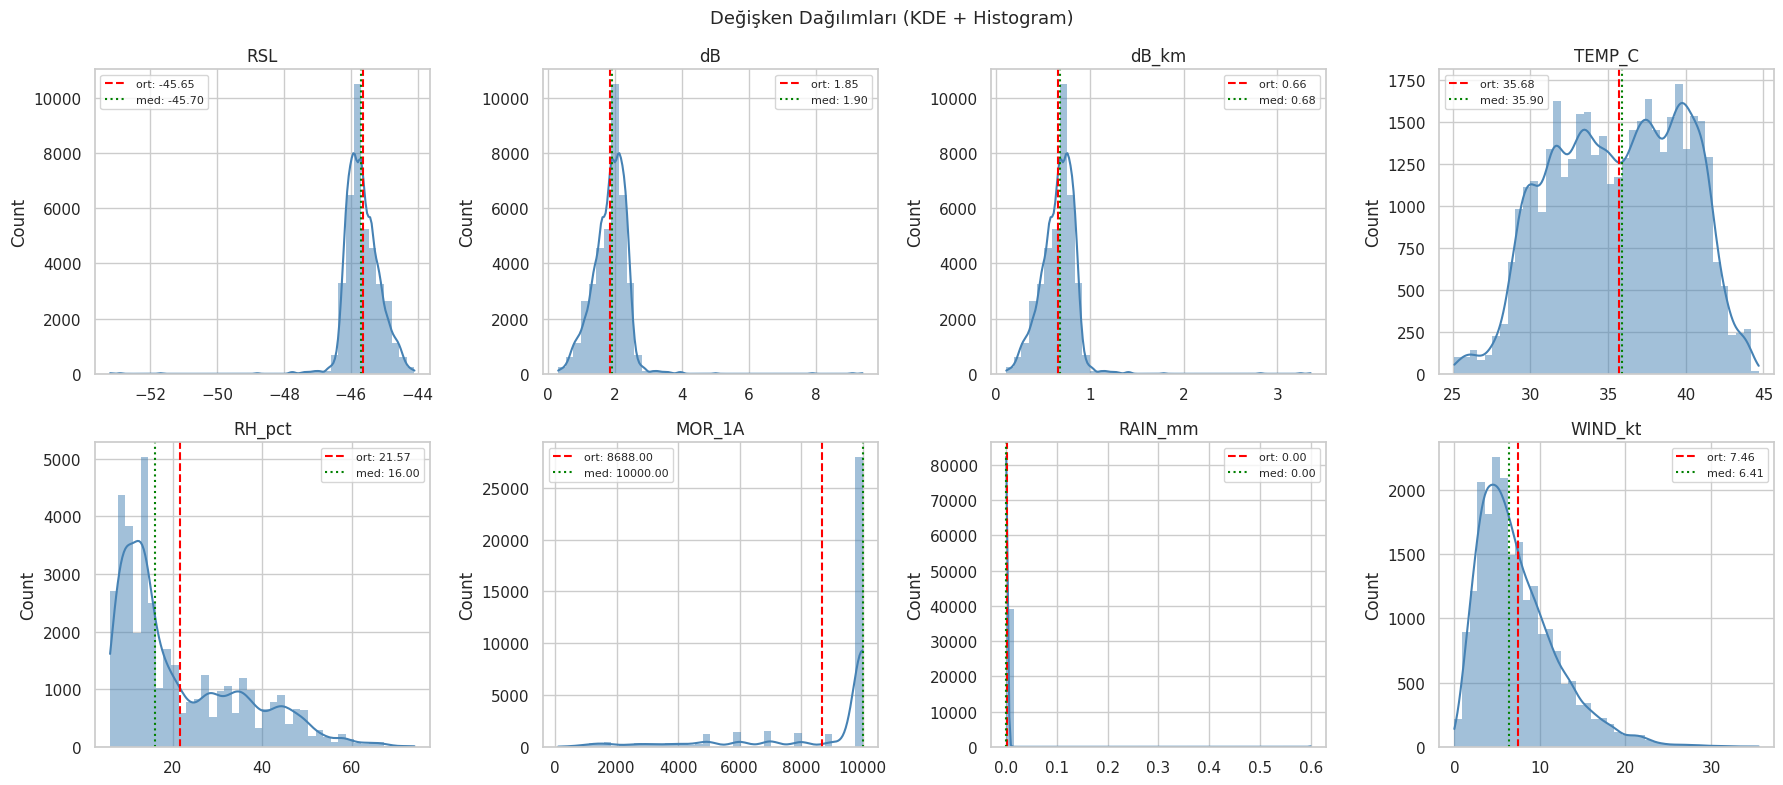

In [15]:
# Her değişken için histogram + KDE (Kernel Density Estimate) grafiği
# Histogram → verinin hangi aralıkta yoğunlaştığını gösterir (çubuklar)
# KDE → sürekli olasılık yoğunluğu tahmini (düzgün eğri)
# Kırmızı kesikli çizgi → ortalama | Yeşil noktalı çizgi → medyan
# Ortalama ≠ medyan ise dağılım çarpık (skewed) demektir
plot_cols = ["RSL", "dB", "dB_km", "TEMP_C", "RH_pct", "MOR_1A", "RAIN_mm", "WIND_kt"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Değişken Dağılımları (KDE + Histogram)", fontsize=13)

for ax, col in zip(axes.flat, plot_cols):
    data = weather[col].dropna()
    sns.histplot(data, kde=True, ax=ax, bins=40, color="steelblue", edgecolor="none")
    ax.axvline(data.mean(),   color="red",   lw=1.5, linestyle="--", label=f"ort: {data.mean():.2f}")
    ax.axvline(data.median(), color="green", lw=1.5, linestyle=":",  label=f"med: {data.median():.2f}")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 10. Aykırı Değer Analizi (Boxplot + IQR)

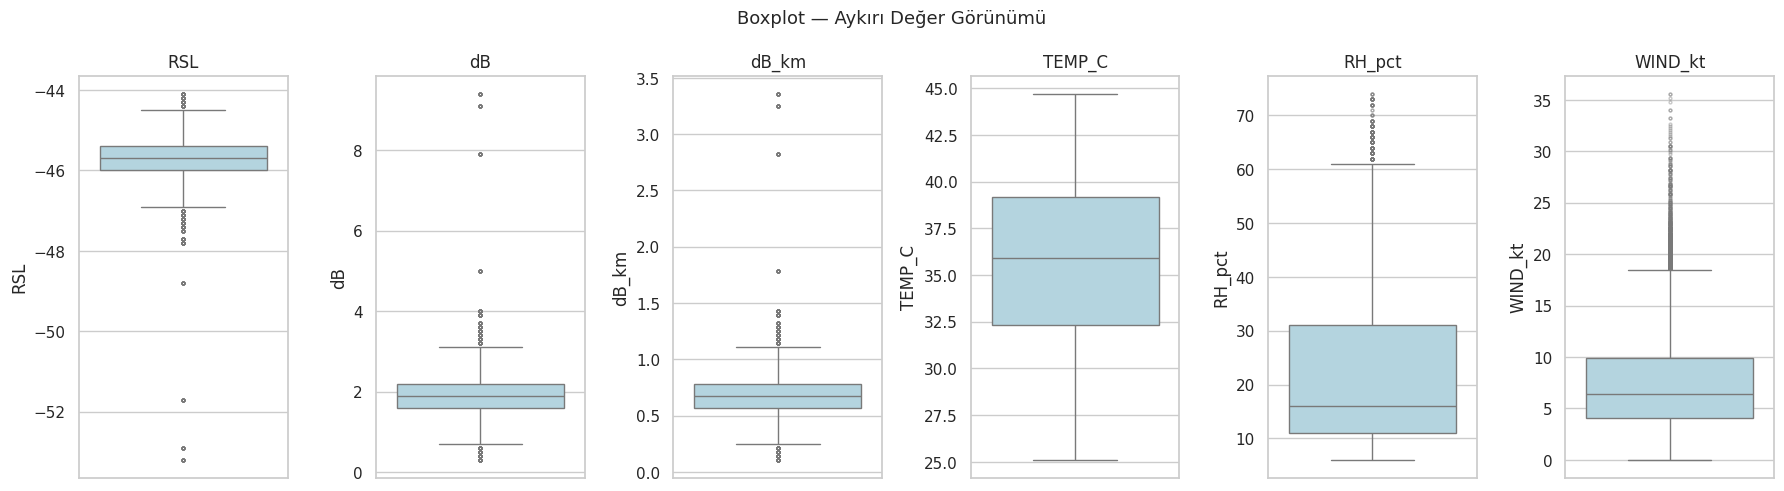


IQR Aykırı Değer Sayıları:


,Q1,Q3,IQR,alt_sınır,üst_sınır,aykırı_sayı,aykırı_pct
değişken,,,,,,,
RSL,-46.0000,-45.4000,0.6000,-46.9000,-44.5000,780,1.9962
dB,1.6000,2.2000,0.6000,0.7000,3.1000,780,1.9962
dB_km,0.5714,0.7857,0.2143,0.2500,1.1071,780,1.9962
TEMP_C,32.3000,39.2000,6.9000,21.9500,49.5500,0,0.0000
RH_pct,11.0000,31.0000,20.0000,-19.0000,61.0000,316,0.8091
WIND_kt,4.0800,9.9100,5.8300,-4.6650,18.6550,624,2.9121


In [16]:
# ── Boxplot ──────────────────────────────────────────────────────────────────
# Boxplot → IQR (Q1-Q3 kutusu), medyan çizgisi ve bıyıkları gösterir.
# Kırmızı noktalar → IQR × 1.5 sınırını aşan aykırı değerler (outlier)
outlier_cols = ["RSL", "dB", "dB_km", "TEMP_C", "RH_pct", "WIND_kt"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
fig.suptitle("Boxplot — Aykırı Değer Görünümü", fontsize=13)

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=weather[col].dropna(), ax=ax, color="lightblue",
                flierprops=dict(marker="o", markersize=2, alpha=0.4, color="red"))
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

# ── IQR Yöntemi ile Aykırı Değer Sayımı ──────────────────────────────────────
# Kural: Q1 - 1.5*IQR altı  VEYA  Q3 + 1.5*IQR üstü → aykırı
print("\nIQR Aykırı Değer Sayıları:")
iqr_rows = []
for col in outlier_cols:
    s = weather[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    iqr_rows.append({"değişken": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "alt_sınır": q1 - 1.5*iqr, "üst_sınır": q3 + 1.5*iqr,
                     "aykırı_sayı": n_out, "aykırı_pct": n_out/len(s)*100})

display(pd.DataFrame(iqr_rows).set_index("değişken"))


## 11. Korelasyon Analizi

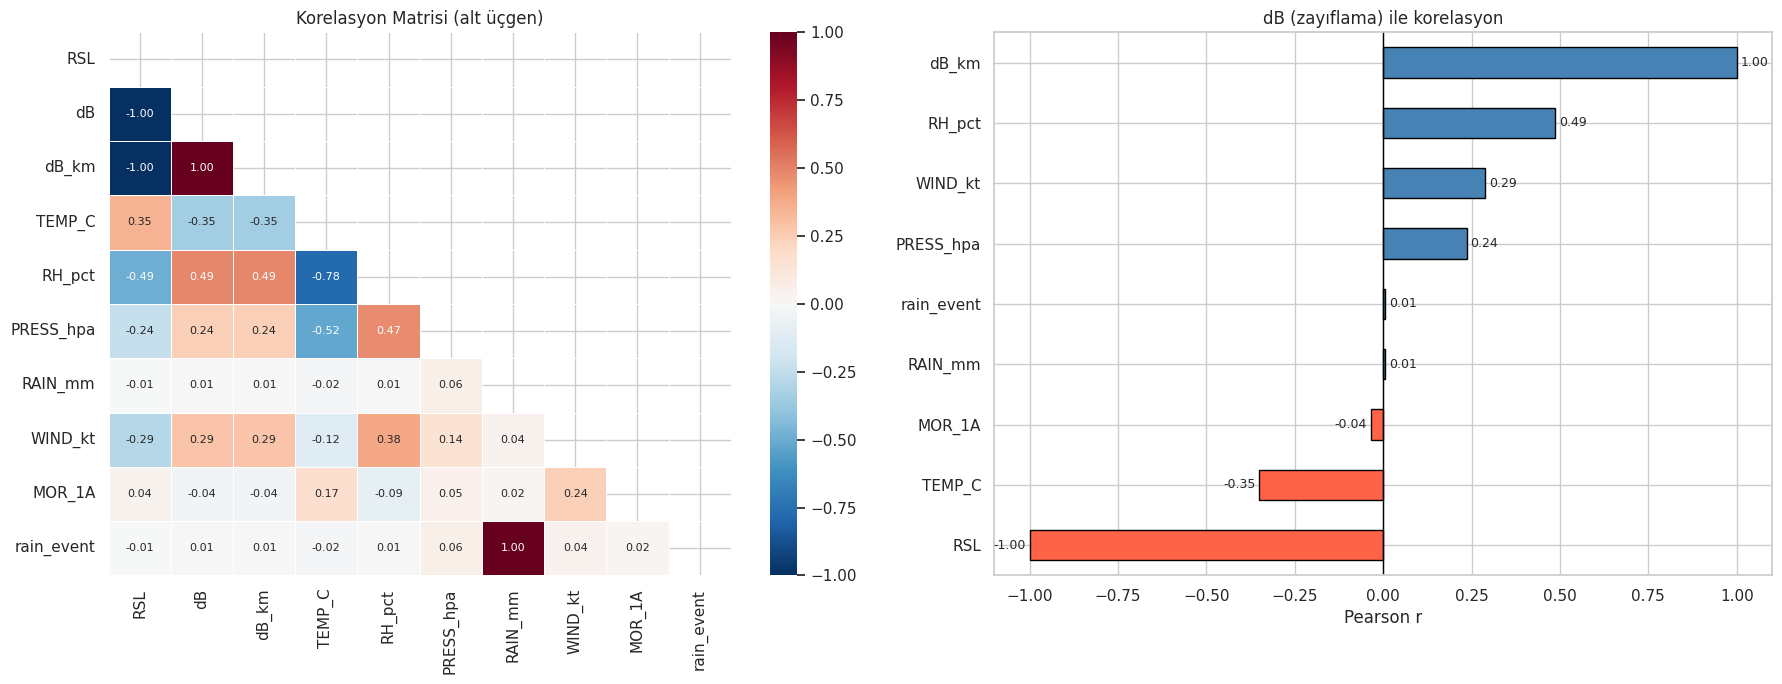

In [17]:
# ── Korelasyon Matrisi ────────────────────────────────────────────────────────
# Pearson korelasyonu: iki değişken arasındaki doğrusal ilişkinin gücü (-1 ile +1 arası)
#  +1 → tam pozitif doğrusal ilişki (biri artınca diğeri de artar)
#  -1 → tam negatif doğrusal ilişki (biri artınca diğeri azalır)
#   0 → doğrusal ilişki yok
corr_cols = ["RSL", "dB", "dB_km", "TEMP_C", "RH_pct", "PRESS_hpa",
             "RAIN_mm", "WIND_kt", "MOR_1A", "rain_event"]
corr_matrix = weather[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol panel: Isı haritası (heatmap) — mask ile üst üçgeni gizliyoruz (tekrar eden bilgi)
# Kırmızı → negatif korelasyon, Mavi → pozitif korelasyon
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={"size": 8})
axes[0].set_title("Korelasyon Matrisi (alt üçgen)")

# Sağ panel: Hedef değişken "dB" ile diğer değişkenlerin korelasyon sıralaması
# Model için hangi özellikler daha belirleyici? → korelasyonu yüksek olanlar
dB_corr = corr_matrix["dB"].drop("dB").sort_values()
colors = ["tomato" if v < 0 else "steelblue" for v in dB_corr]
dB_corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="black")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("dB (zayıflama) ile korelasyon")
axes[1].set_xlabel("Pearson r")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.2f}",
                     (p.get_width() + (0.01 if p.get_width() >= 0 else -0.01),
                      p.get_y() + p.get_height() / 2),
                     va="center", ha="left" if p.get_width() >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()


## 12. Günlük Örüntü — Saatlik Ortalamalar

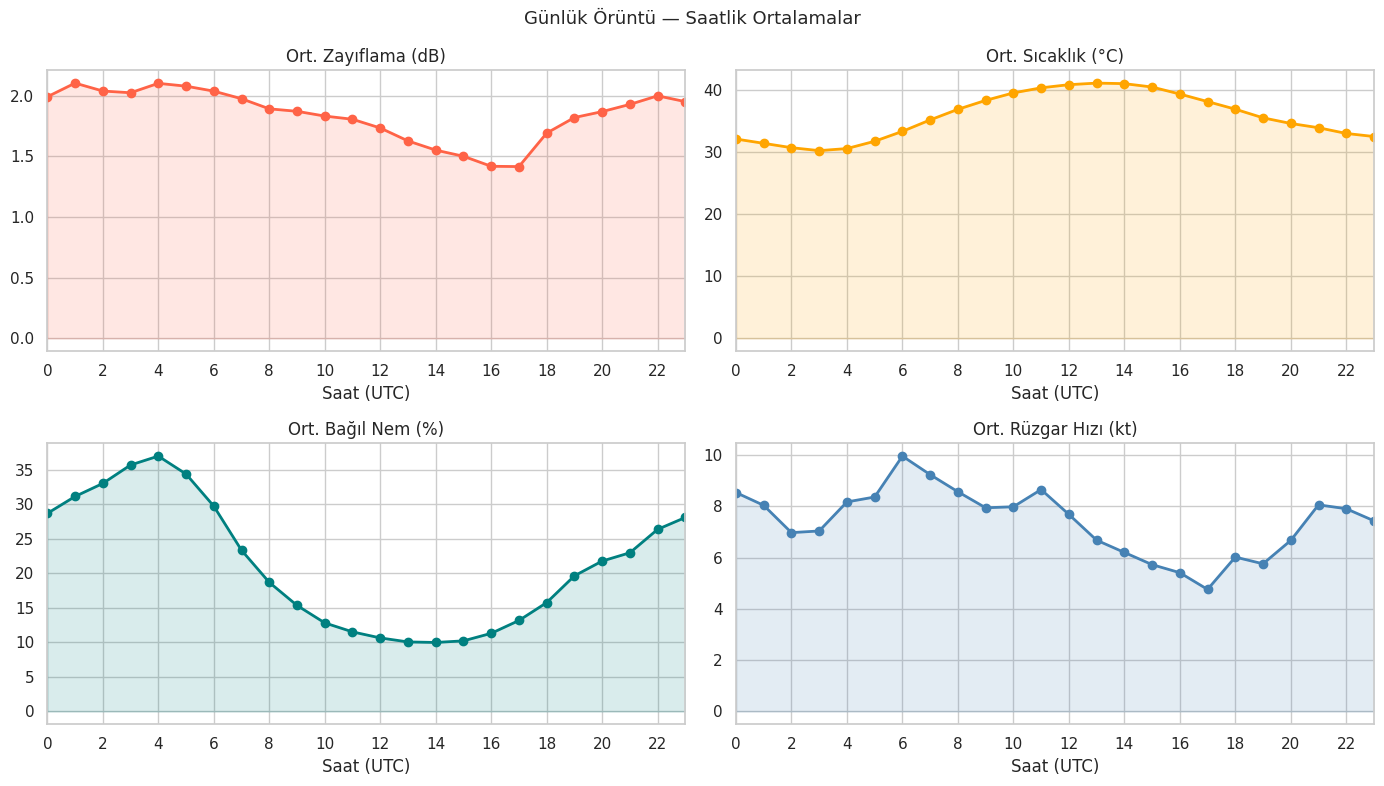

In [18]:
# Tüm veri döneminin saatlik ortalamaları → günlük örüntüyü (diurnal pattern) ortaya çıkarır.
# Örneğin sıcaklık öğlen zirveye ulaşıyorsa, zayıflama da aynı saatlerde artıyor mu?
hourly = weather.groupby("hour")[["dB", "TEMP_C", "RH_pct", "WIND_kt"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Günlük Örüntü — Saatlik Ortalamalar", fontsize=13)

for ax, (col, color, title) in zip(axes.flat, [
    ("dB",      "tomato",    "Ort. Zayıflama (dB)"),
    ("TEMP_C",  "orange",    "Ort. Sıcaklık (°C)"),
    ("RH_pct",  "teal",      "Ort. Bağıl Nem (%)"),
    ("WIND_kt", "steelblue", "Ort. Rüzgar Hızı (kt)"),
]):
    ax.plot(hourly.index, hourly[col], marker="o", color=color, lw=2)
    ax.fill_between(hourly.index, hourly[col], alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel("Saat (UTC)")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(0, 23)

plt.tight_layout()
plt.show()


## 13. Scatter — Meteoroloji vs Zayıflama

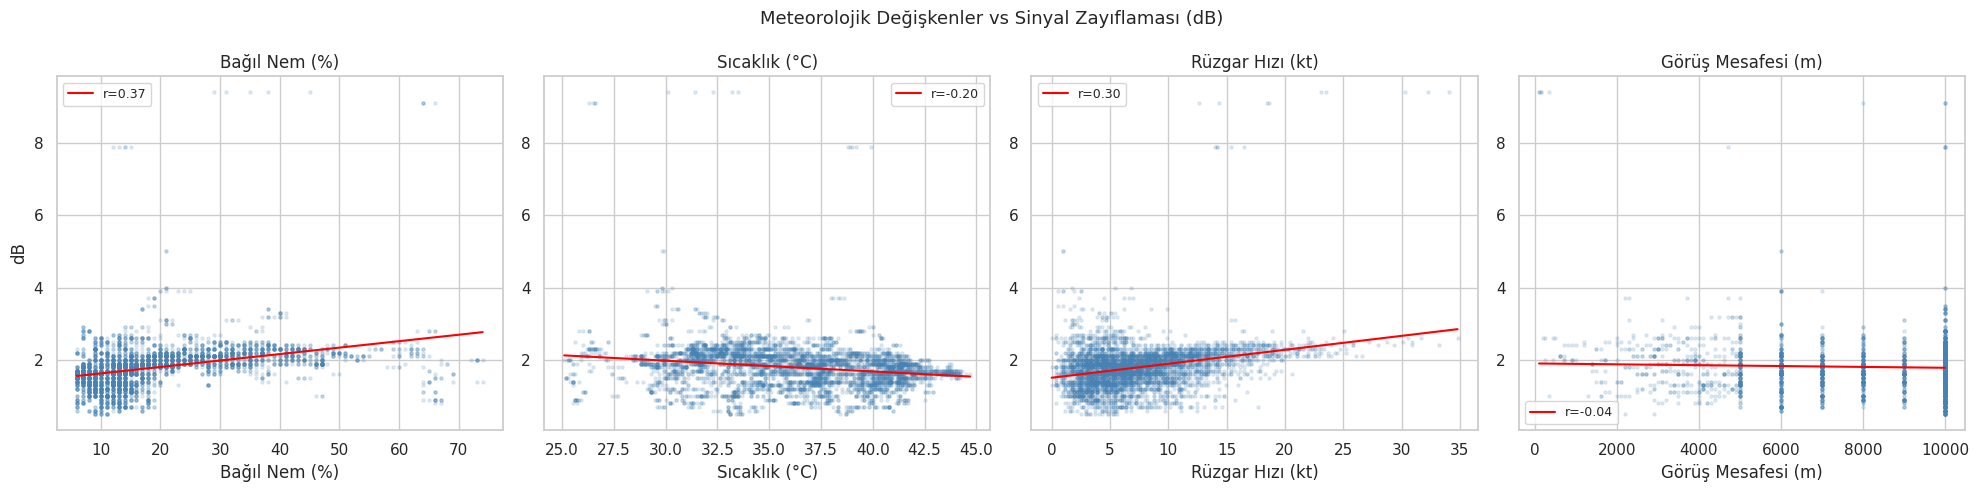

In [19]:
# Scatter (saçılım) grafiği + regresyon doğrusu
# Her nokta bir dakikalık ölçüm. Çok fazla nokta olduğundan alpha=0.15 ile şeffaflık veriyoruz.
# Kırmızı doğru → lineer regresyon fit'i, r → Pearson korelasyon katsayısı
# r değeri grafiğin başlığında gösteriliyor: |r| > 0.3 anlamlı ilişkiye işaret eder
scatter_cols = [("RH_pct", "Bağıl Nem (%)"),
                ("TEMP_C", "Sıcaklık (°C)"),
                ("WIND_kt", "Rüzgar Hızı (kt)"),
                ("MOR_1A", "Görüş Mesafesi (m)")]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Meteorolojik Değişkenler vs Sinyal Zayıflaması (dB)", fontsize=13)

# 39K noktanın tamamı yerine rastgele 5000 örnek çekiyoruz (daha hızlı ve okunabilir)
w_sample = weather.dropna(subset=["dB", "RH_pct", "TEMP_C", "WIND_kt", "MOR_1A"]).sample(
    n=min(5000, len(weather)), random_state=42)

for ax, (col, label) in zip(axes, scatter_cols):
    ax.scatter(w_sample[col], w_sample["dB"],
               alpha=0.15, s=5, color="steelblue", rasterized=True)
    # scipy.stats.linregress → eğim (m), sabit (b), korelasyon (r), p-değeri
    m, b, r, p, _ = stats.linregress(w_sample[col].dropna(),
                                      w_sample.loc[w_sample[col].notna(), "dB"])
    x_line = np.linspace(w_sample[col].min(), w_sample[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color="red", lw=1.5, label=f"r={r:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("dB" if col == "RH_pct" else "")
    ax.legend(fontsize=9)
    ax.set_title(label)

plt.tight_layout()
plt.show()


## 14. Yağış Olayı Karşılaştırması (Rain vs No-Rain)

/tmp/ipykernel_15934/673844681.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weather_box, x="Durum", y="dB", ax=axes[1],


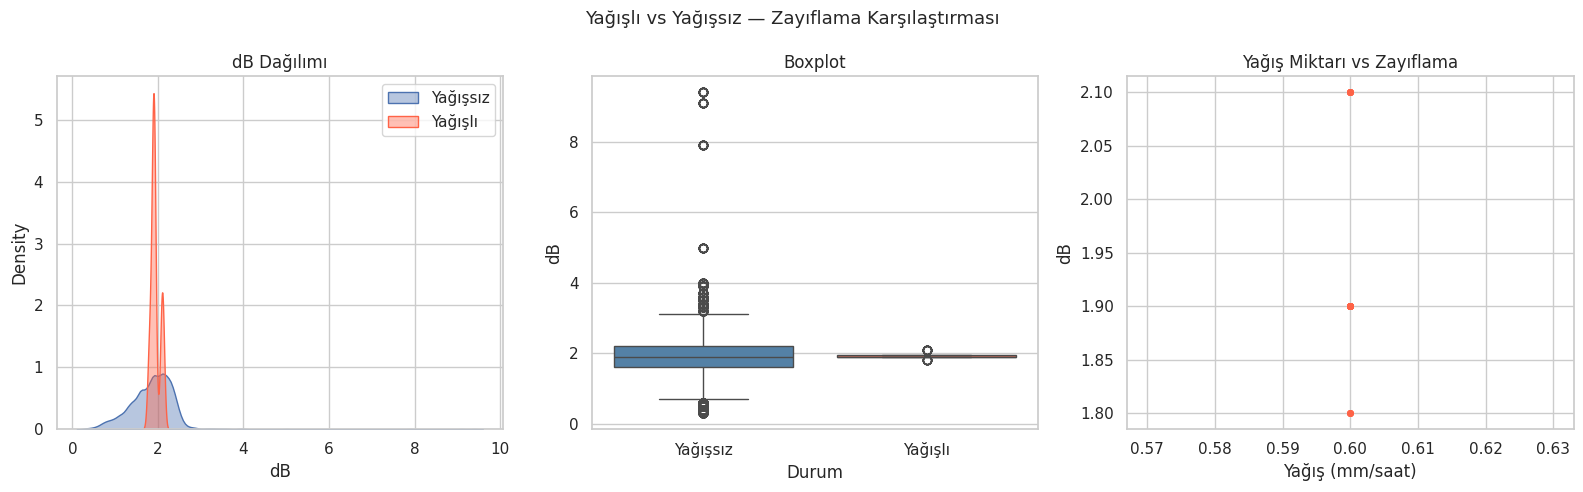

Yağışlı   — ort: 1.935 dB, n=60
Yağışsız  — ort: 1.851 dB, n=39014
t-test: t=1.212, p=0.2256 (anlamlı fark yok)


In [20]:
# Yağışlı ve yağışsız dönemlerdeki zayıflama değerlerini karşılaştırıyoruz
rain_yes = weather[weather["rain_event"] == 1]["dB"].dropna()
rain_no  = weather[weather["rain_event"] == 0]["dB"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Yağışlı vs Yağışsız — Zayıflama Karşılaştırması", fontsize=13)

# Panel 1: KDE (yoğunluk eğrisi) — iki grubun dağılımı üst üste
# Eğriler örtüşmüyorsa yağışın zayıflamaya belirgin etkisi var demektir
sns.kdeplot(rain_no,  ax=axes[0], label="Yağışsız", fill=True, alpha=0.4)
sns.kdeplot(rain_yes, ax=axes[0], label="Yağışlı",  fill=True, alpha=0.4, color="tomato")
axes[0].set_xlabel("dB"); axes[0].set_title("dB Dağılımı")
axes[0].legend()

# Panel 2: Boxplot — medyan, IQR ve aykırı değerleri grup bazında gösterir
weather_box = weather[["dB", "rain_event"]].dropna()
weather_box["Durum"] = weather_box["rain_event"].map({0: "Yağışsız", 1: "Yağışlı"})
sns.boxplot(data=weather_box, x="Durum", y="dB", ax=axes[1],
            palette={"Yağışsız": "steelblue", "Yağışlı": "tomato"})
axes[1].set_title("Boxplot")

# Panel 3: Yağış miktarı (mm) ile zayıflama (dB) ilişkisi — sadece yağışlı anlar
# Noktalar yukarı kümeleniyorsa yağış şiddeti arttıkça zayıflama da artıyor demektir
rain_data = weather[weather["rain_event"] == 1][["RAIN_mm", "dB"]].dropna()
axes[2].scatter(rain_data["RAIN_mm"], rain_data["dB"], alpha=0.5, color="tomato", s=15)
axes[2].set_xlabel("Yağış (mm/saat)")
axes[2].set_ylabel("dB")
axes[2].set_title("Yağış Miktarı vs Zayıflama")

plt.tight_layout()
plt.show()

# Bağımsız iki örneklem t-testi:
# H0 → yağışlı ve yağışsız grupların zayıflama ortalamaları eşittir
# p < 0.05 → H0 reddedilir, gruplar arasında istatistiksel olarak anlamlı fark vardır
t_stat, p_val = stats.ttest_ind(rain_yes, rain_no)
print(f"Yağışlı   — ort: {rain_yes.mean():.3f} dB, n={len(rain_yes)}")
print(f"Yağışsız  — ort: {rain_no.mean():.3f} dB, n={len(rain_no)}")
print(f"t-test: t={t_stat:.3f}, p={p_val:.4f} {'(anlamlı fark)' if p_val < 0.05 else '(anlamlı fark yok)'}")


## 15. Modelleme İçin Hazır DataFrame

Buraya kadar tamamlanan temizlik ve encoding sonucu `weather_model` adlı DataFrame modellemeye hazır haldedir.

In [21]:
# Modelleme için kullanılacak özellikler (feature) ve hedef (target) tanımlanıyor.
# Hedef: dB → sinyal zayıflaması (ne kadar büyükse o kadar kötü bağlantı)
feature_cols = [
    "TEMP_C",          # Sıcaklık — atmosferik kırılmayı etkiler
    "RH_pct",          # Bağıl nem — yüksek nem zayıflamayı artırır
    "PRESS_hpa",       # Atmosferik basınç
    "RAIN_mm",         # Yağış miktarı — en güçlü zayıflama faktörü
    "WIND_kt",         # Rüzgar hızı
    "MOR_1A",          # Görüş mesafesi — sis/yağış yoğunluğunun dolaylı göstergesi
    "rain_event",      # Yağış var/yok (binary)
    "time_of_day_ord", # Günün dilimi (ordinal: 0-3)
    "tod_gece", "tod_sabah", "tod_öğle", "tod_akşam",  # One-hot dummies
    "hour",            # Saat (0-23) — günlük örüntü için
]
target_col = "dB"

# Hedef sütunda NaN olan satırları çıkarıyoruz
weather_model = weather[feature_cols + [target_col]].dropna(subset=[target_col])

print(f"Modelleme DataFrame şekli: {weather_model.shape}")
print(f"Özellikler ({len(feature_cols)}): {feature_cols}")
print(f"Hedef      : {target_col}")
print(f"\nEksik değer sayıları:")
display(weather_model.isna().sum()[weather_model.isna().sum() > 0])
display(weather_model.describe().T)


Modelleme DataFrame şekli: (39074, 14)
Özellikler (13): ['TEMP_C', 'RH_pct', 'PRESS_hpa', 'RAIN_mm', 'WIND_kt', 'MOR_1A', 'rain_event', 'time_of_day_ord', 'tod_gece', 'tod_sabah', 'tod_öğle', 'tod_akşam', 'hour']
Hedef      : dB

Eksik değer sayıları:


TEMP_C          15
RH_pct          16
PRESS_hpa       14
RAIN_mm         13
WIND_kt      17646
MOR_1A          26
dtype: int64

,count,mean,std,min,25%,50%,75%,max
TEMP_C,"39,059.0000",35.6842,4.1299,25.1000,32.3000,35.9000,39.2000,44.7000
RH_pct,"39,058.0000",21.5730,13.8659,6.0000,11.0000,16.0000,31.0000,74.0000
PRESS_hpa,"39,060.0000",963.8403,2.1236,958.5000,962.3000,964.0000,965.5000,968.8000
RAIN_mm,"39,061.0000",0.0009,0.0235,0.0000,0.0000,0.0000,0.0000,0.6000
WIND_kt,"21,428.0000",7.4556,4.6874,0.0000,4.0800,6.4100,9.9100,35.5700
MOR_1A,"39,048.0000","8,688.0032","2,461.2939",100.0000,"8,000.0000","10,000.0000","10,000.0000","10,000.0000"
rain_event,"39,074.0000",0.0015,0.0392,0.0000,0.0000,0.0000,0.0000,1.0000
time_of_day_ord,"39,074.0000",1.4883,1.1281,0.0000,0.0000,1.0000,3.0000,3.0000
tod_gece,"39,074.0000",0.2580,0.4375,0.0000,0.0000,0.0000,1.0000,1.0000
tod_sabah,"39,074.0000",0.2491,0.4325,0.0000,0.0000,0.0000,0.0000,1.0000


---

# Modelleme

Hedef: **`dB`** (sinyal zayıflaması)  
Modeller: **Linear Regression · Random Forest · Gradient Boosting**  
Akış: varsayılan parametreler → GridSearchCV (cv=5) → karşılaştırma

In [22]:
# Modelleme kütüphanelerini içe aktarıyoruz
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer  # NaN değerleri doldurmak için
import warnings
warnings.filterwarnings('ignore')

# ── Train / Test Split ────────────────────────────────────────────────────────
# Veriyi %80 eğitim, %20 test olarak bölüyoruz.
# random_state=42 → her çalıştırmada aynı bölünmeyi garanti eder (tekrarlanabilirlik)
X = weather_model[feature_cols]
y = weather_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} kayıt")
print(f"Test : {X_test.shape[0]} kayıt")
print(f"Özellik sayısı: {X_train.shape[1]}")


Train: 31259 kayıt
Test : 7815 kayıt
Özellik sayısı: 13


## 16. Varsayılan Parametrelerle Eğitim

In [23]:
# ── Pipeline Yapısı ───────────────────────────────────────────────────────────
# Pipeline → adımları sırayla uygular; veri sızıntısı (data leakage) riskini azaltır.
# Adım 1 — SimpleImputer: NaN değerleri medyan ile doldurur
#   (medyan, aykırı değerlere ortalamadan daha dirençli)
# Adım 2 — model: seçilen regresyon algoritması
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model)
    ])

# ── Metrik Hesaplama Fonksiyonu ───────────────────────────────────────────────
# MSE  → Mean Squared Error: hataların karelerinin ortalaması (büyük hatalara ağırlık verir)
# RMSE → Root MSE: MSE'nin karekökü, hedef değişkenle aynı birimde (dB)
# R²   → Determination katsayısı: modelin varyansı ne kadar açıkladığı (1 = mükemmel)
# CV R²→ 5-fold cross-validation R² — sadece train set üzerinde, aşırı uyumu sınarız
def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_te, y_pred)
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'R²': r2, 'CV R² (train)': cv_r2}

# ── Üç Model — Varsayılan Hiperparametreler ───────────────────────────────────
# LinearRegression  → doğrusal ilişkiyi öğrenir; hızlı ama karmaşık örüntüleri kaçırır
# RandomForest      → çok sayıda karar ağacının ortalaması; aşırı uyuma dayanıklı
# GradientBoosting  → ağaçları sırayla ekler, her biri öncekinin hatasını düzeltir
default_models = {
    'LinearRegression' : LinearRegression(),
    'RandomForest'     : RandomForestRegressor(random_state=42),
    'GradientBoosting' : GradientBoostingRegressor(random_state=42),
}

default_results = []
default_pipes   = {}

for name, model in default_models.items():
    pipe = make_pipeline(model)
    res  = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    default_results.append(res)
    default_pipes[name] = pipe
    print(f"{name:<22}  MSE={res['MSE']:.4f}  RMSE={res['RMSE']:.4f}  R²={res['R²']:.4f}  CV-R²={res['CV R² (train)']:.4f}")

df_default = pd.DataFrame(default_results).set_index('Model')
print('\nVarsayılan model sonuçları:')
display(df_default)


LinearRegression        MSE=0.1694  RMSE=0.4115  R²=0.3104  CV-R²=0.2671
RandomForest            MSE=0.0287  RMSE=0.1693  R²=0.8833  CV-R²=0.8763
GradientBoosting        MSE=0.1182  RMSE=0.3438  R²=0.5186  CV-R²=0.5472

Varsayılan model sonuçları:


,MSE,RMSE,R²,CV R² (train)
Model,,,,
LinearRegression,0.1694,0.4115,0.3104,0.2671
RandomForest,0.0287,0.1693,0.8833,0.8763
GradientBoosting,0.1182,0.3438,0.5186,0.5472


## 17. GridSearchCV ile Hiperparametre Optimizasyonu (cv=5)

In [24]:
# ── GridSearchCV — Hiperparametre Arama ──────────────────────────────────────
# GridSearchCV tüm parametre kombinasyonlarını dener ve en iyi olanı seçer.
# cv=5 → veriyi 5 parçaya böler, her seferinde 4 parça train + 1 parça validasyon
# n_jobs=-1 → tüm CPU çekirdeklerini paralel kullanır (daha hızlı)
# scoring='r2' → en iyi parametre seti R² metriğine göre seçilir

param_grids = {
    'LinearRegression': {
        # fit_intercept=True → modele sabit terim (bias) ekler (genelde True daha iyi)
        'model__fit_intercept': [True, False],
        'model__positive': [False],
    },
    'RandomForest': {
        # n_estimators → kaç ağaç kullanılacak (fazla = iyi ama yavaş)
        'model__n_estimators'    : [100, 200],
        # max_depth → ağacın maksimum derinliği (None = tam derinlik; aşırı uyum riski)
        'model__max_depth'       : [None, 10, 20],
        # min_samples_split → bir düğümün bölünebilmesi için gereken minimum örnek sayısı
        'model__min_samples_split': [2, 5],
    },
    'GradientBoosting': {
        'model__n_estimators'  : [100, 200],
        # learning_rate → her ağacın katkısının küçültme katsayısı (küçük = daha yavaş ama stabil)
        'model__learning_rate' : [0.05, 0.1],
        'model__max_depth'     : [3, 5],
        # subsample → her ağaç için kullanılacak veri oranı (< 1.0 → stochastic GBM)
        'model__subsample'     : [0.8, 1.0],
    },
}

grid_results = []
best_pipes   = {}

for name, model in default_models.items():
    # Her model için taze bir pipeline oluşturuyoruz (önceki fit'in etkisini sıfırlamak için)
    base = model.__class__(random_state=42) if hasattr(model, 'random_state') else model.__class__()
    pipe = make_pipeline(base)
    grid = GridSearchCV(pipe, param_grids[name], cv=5,
                        scoring='r2', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    mse    = mean_squared_error(y_test, y_pred)
    rmse   = mse ** 0.5
    r2     = r2_score(y_test, y_pred)
    cv_r2  = grid.best_score_   # En iyi parametrenin CV skoru

    best_pipes[name] = grid
    grid_results.append({'Model': name, 'MSE': mse, 'RMSE': rmse,
                         'R²': r2, 'CV R² (train)': cv_r2,
                         'Best Params': grid.best_params_})
    print(f"{name:<22}  best CV-R²={cv_r2:.4f}  test R²={r2:.4f}")
    print(f"  Best params: {grid.best_params_}\n")

df_grid = pd.DataFrame(grid_results).set_index('Model')
print('GridSearchCV sonuçları:')
display(df_grid.drop(columns='Best Params'))


LinearRegression        best CV-R²=0.2671  test R²=0.3104
  Best params: {'model__fit_intercept': False, 'model__positive': False}

RandomForest            best CV-R²=0.8763  test R²=0.8833
  Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

GradientBoosting        best CV-R²=0.7781  test R²=0.7622
  Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

GridSearchCV sonuçları:


,MSE,RMSE,R²,CV R² (train)
Model,,,,
LinearRegression,0.1694,0.4115,0.3104,0.2671
RandomForest,0.0287,0.1693,0.8833,0.8763
GradientBoosting,0.0584,0.2417,0.7622,0.7781


## 18. Karşılaştırma — Varsayılan vs GridSearch

In [25]:
# İki eğitim yönteminin metriklerini yan yana birleştiriyoruz
metrics = ['MSE', 'RMSE', 'R²', 'CV R² (train)']

# Sütun adlarına prefix ekleyerek hangisinin Default hangisinin Grid olduğunu ayırt ediyoruz
df_default.columns  = [f'Default_{c}' for c in df_default.columns]
df_grid_cmp = df_grid.drop(columns='Best Params').copy()
df_grid_cmp.columns = [f'Grid_{c}' for c in df_grid_cmp.columns]

compare = pd.concat([df_default, df_grid_cmp], axis=1)
print('Tam karşılaştırma tablosu:')
display(compare)

# Delta tablosu: Grid - Default
# R² için → pozitif delta = iyileşme
# MSE/RMSE için → negatif delta = iyileşme (hata azaldı)
delta = pd.DataFrame(index=compare.index)
for m in metrics:
    delta[f'Δ {m}'] = df_grid_cmp[f'Grid_{m}'] - df_default[f'Default_{m}']

print('\nGelişim (Grid - Default):')
display(delta.style.background_gradient(cmap='RdYlGn', axis=None))


Tam karşılaştırma tablosu:


,Default_MSE,Default_RMSE,Default_R²,Default_CV R² (train),Grid_MSE,Grid_RMSE,Grid_R²,Grid_CV R² (train)
Model,,,,,,,,
LinearRegression,0.1694,0.4115,0.3104,0.2671,0.1694,0.4115,0.3104,0.2671
RandomForest,0.0287,0.1693,0.8833,0.8763,0.0287,0.1693,0.8833,0.8763
GradientBoosting,0.1182,0.3438,0.5186,0.5472,0.0584,0.2417,0.7622,0.7781



Gelişim (Grid - Default):


,Δ MSE,Δ RMSE,Δ R²,Δ CV R² (train)
Model,,,,
LinearRegression,0.000000,0.000000,-0.000000,0.000000
RandomForest,0.000000,0.000000,0.000000,0.000000
GradientBoosting,-0.059828,-0.102182,0.243613,0.230908


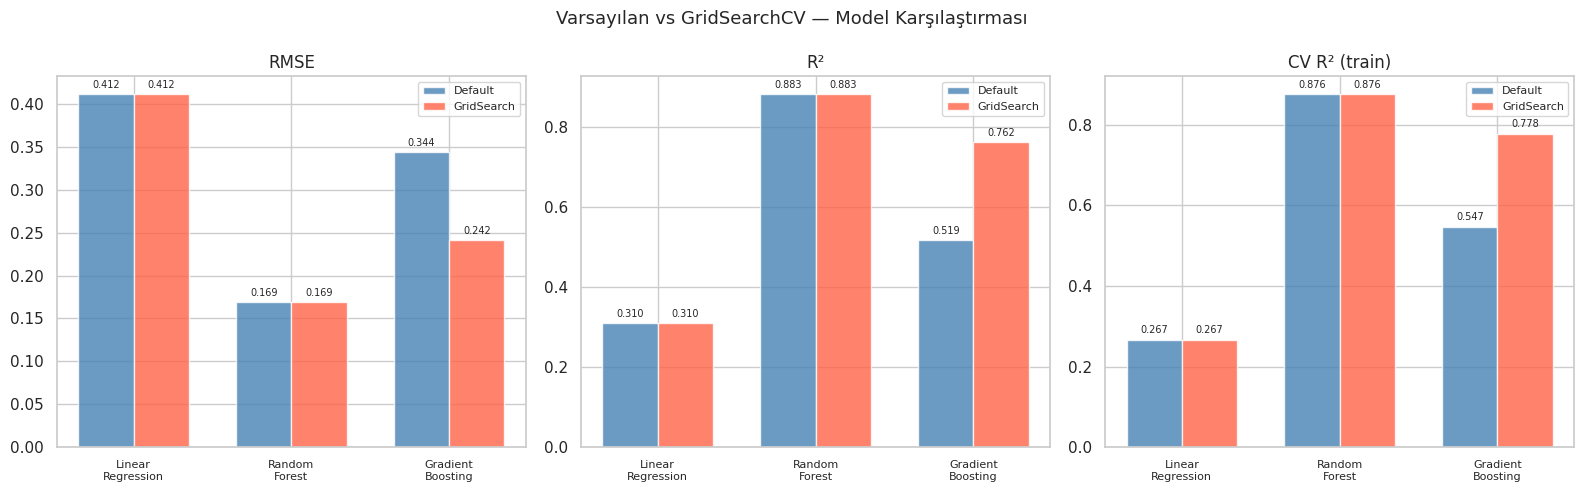

In [26]:
# Üç metriği bar grafikleriyle karşılaştırıyoruz
# Mavi çubuk = varsayılan, Kırmızı çubuk = GridSearch
# RMSE düşük olması iyi, R² yüksek olması iyi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Varsayılan vs GridSearchCV — Model Karşılaştırması', fontsize=13)

model_names = list(default_models.keys())
x     = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, ['RMSE', 'R²', 'CV R² (train)']):
    d_vals = [df_default.loc[m, f'Default_{metric}'] for m in model_names]
    g_vals = [df_grid_cmp.loc[m, f'Grid_{metric}']   for m in model_names]

    bars1 = ax.bar(x - width/2, d_vals, width, label='Default',    color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, g_vals, width, label='GridSearch', color='tomato',    alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('Regression','\nRegression')
                         .replace('Forest','\nForest')
                         .replace('Boosting','\nBoosting') for m in model_names], fontsize=8)
    ax.set_title(metric)
    ax.legend(fontsize=8)

    # Her çubuğun üstüne değerini yazıyoruz
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


## 19. Feature Importance (RF & GBoost)

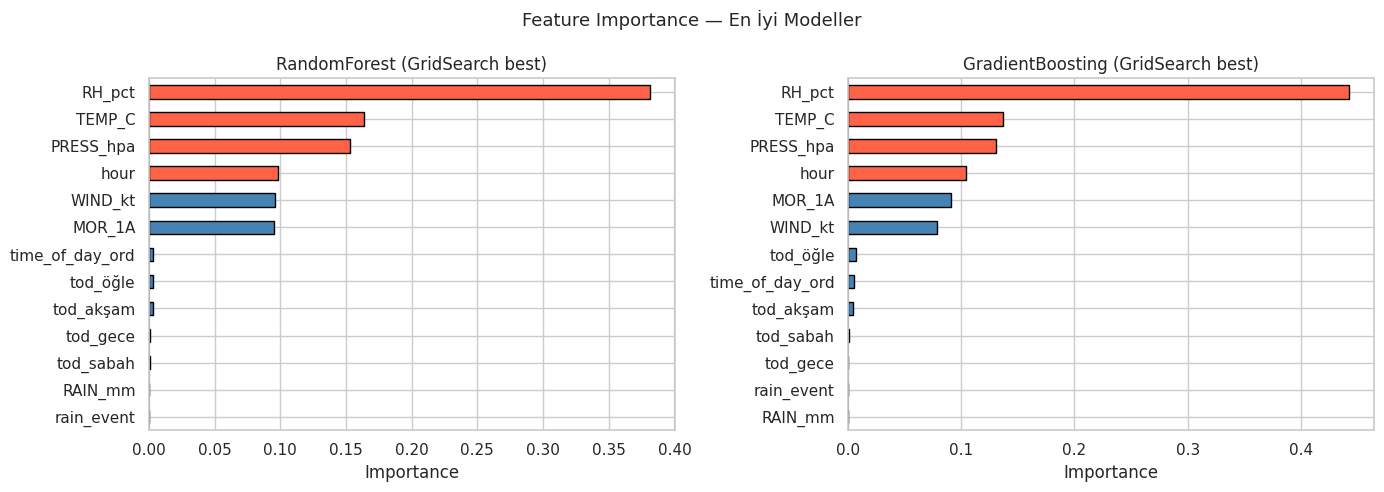

In [27]:
# Feature Importance → modelin tahmin yaparken hangi değişkene ne kadar güvendiğini gösterir.
# Değer ne kadar yüksekse o değişken modelin kararlarında o kadar belirleyici demektir.
# LinearRegression'ın katsayıları ölçek bağımlı olduğundan burada sadece ağaç modelleri gösteriliyor.
# Kırmızı çubuklar → üst çeyreğe (Q75) giren, yani en önemli özellikler
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — En İyi Modeller (GridSearch)', fontsize=13)

for ax, name in zip(axes, ['RandomForest', 'GradientBoosting']):
    # GridSearch'ün bulduğu en iyi pipeline'dan model adımını çıkarıyoruz
    best_model = best_pipes[name].best_estimator_.named_steps['model']
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    colors = ['tomato' if v >= importances.quantile(0.75) else 'steelblue' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'{name} (GridSearch best)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


## 20. Residual (Hata) Analizi

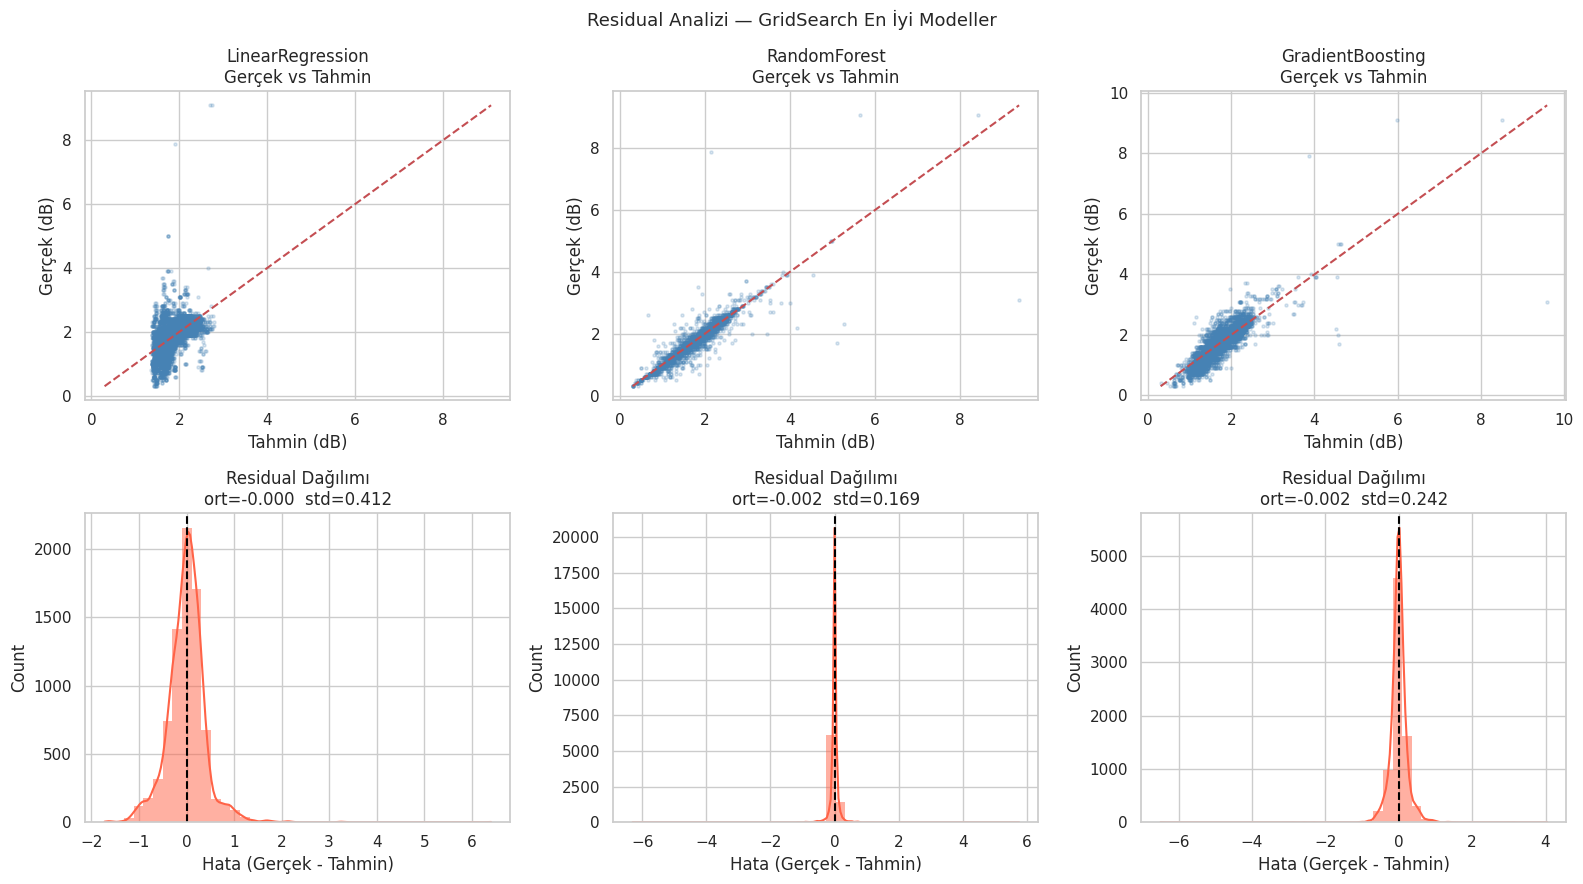

In [28]:
# Residual (hata) analizi → modelin sistematik hata yapıp yapmadığını kontrol eder.
#
# Üst satır — Gerçek vs Tahmin scatter:
#   Noktalar kırmızı diyagonal çizgiye ne kadar yakınsa model o kadar iyi.
#   Diyagonalden sapma = hata. Belirli bir bölgede yoğun sapma varsa model orada kör demektir.
#
# Alt satır — Residual dağılımı (hata histogramı):
#   İyi bir model: hatalar 0 etrafında simetrik ve normal dağılımlı olmalı.
#   Sola/sağa kayma → sistematik hata (bias) var demektir.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Residual Analizi — GridSearch En İyi Modeller', fontsize=13)

for col_idx, name in enumerate(model_names):
    y_pred    = best_pipes[name].predict(X_test)
    residuals = y_test.values - y_pred   # Gerçek - Tahmin

    # Gerçek vs Tahmin
    axes[0, col_idx].scatter(y_pred, y_test.values, alpha=0.2, s=5, color='steelblue')
    lims = [min(y_pred.min(), y_test.min()), max(y_pred.max(), y_test.max())]
    axes[0, col_idx].plot(lims, lims, 'r--', lw=1.5)   # Mükemmel tahmin çizgisi
    axes[0, col_idx].set_xlabel('Tahmin (dB)')
    axes[0, col_idx].set_ylabel('Gerçek (dB)')
    axes[0, col_idx].set_title(f'{name}\nGerçek vs Tahmin')

    # Residual dağılımı
    sns.histplot(residuals, kde=True, ax=axes[1, col_idx], bins=40,
                 color='tomato', edgecolor='none')
    axes[1, col_idx].axvline(0, color='black', lw=1.5, linestyle='--')
    axes[1, col_idx].set_xlabel('Hata (Gerçek - Tahmin)')
    axes[1, col_idx].set_title(
        f'Residual Dağılımı\nort={residuals.mean():.3f}  std={residuals.std():.3f}')

plt.tight_layout()
plt.show()


## 21. Özet Tablo — Tüm Metrikler

In [29]:
# Tüm modellerin (Default + GridSearch) metriklerini tek tabloda topluyoruz
# Renkli gradient → en iyi değerleri bir bakışta görmek için
#   R²   sütunu: YeşilSarı → yüksek R² daha iyi
#   MSE/RMSE: YeşilSarı → düşük hata daha iyi (cmap ters çevrilmiş)
rows = []
for name in model_names:
    for label, pipe in [('Default', default_pipes[name]), ('GridSearch', best_pipes[name])]:
        y_pred = pipe.predict(X_test)
        mse    = mean_squared_error(y_test, y_pred)
        rows.append({
            'Model'  : name,
            'Yöntem' : label,
            'MSE'    : round(mse, 5),
            'RMSE'   : round(mse**0.5, 5),
            'R²'     : round(r2_score(y_test, y_pred), 5),
        })

summary = pd.DataFrame(rows)
print('Tüm Model Sonuçları:')
display(
    summary.style
    .background_gradient(subset=['R²'],        cmap='YlGn')
    .background_gradient(subset=['RMSE','MSE'], cmap='YlOrRd_r')
    .format({'MSE': '{:.5f}', 'RMSE': '{:.5f}', 'R²': '{:.5f}'})
)

# En iyi modeli R² bazında seçip ekrana yazdırıyoruz
best_row = summary.loc[summary['R²'].idxmax()]
print(f"\nEn iyi model: {best_row['Model']} ({best_row['Yöntem']})")
print(f"  R²   = {best_row['R²']:.5f}")
print(f"  RMSE = {best_row['RMSE']:.5f}")


Tüm Model Sonuçları:


,Model,Yöntem,MSE,RMSE,R²
0,LinearRegression,Default,0.16936,0.41153,0.31041
1,LinearRegression,GridSearch,0.16936,0.41153,0.31041
2,RandomForest,Default,0.02867,0.16932,0.88327
3,RandomForest,GridSearch,0.02867,0.16932,0.88327
4,GradientBoosting,Default,0.11823,0.34385,0.51859
5,GradientBoosting,GridSearch,0.05840,0.24166,0.76220



En iyi model: RandomForest (Default)
  R² = 0.88327
  RMSE = 0.16932
